# E-Commerce Sales Data Analysis using Python

# Import Libraries

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")



## Load Dataset

In [32]:
df = pd.read_csv("../data/superstore_sales.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## Data Overview

In [ ]:
df.shape
df.info()
df.describe()

(9800, 18)

## Data Preparation

In [42]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Order Date'].head()
df['Month'] = df['Order Date'].dt.month
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,10


## Visual Analysis


## Sales by Category

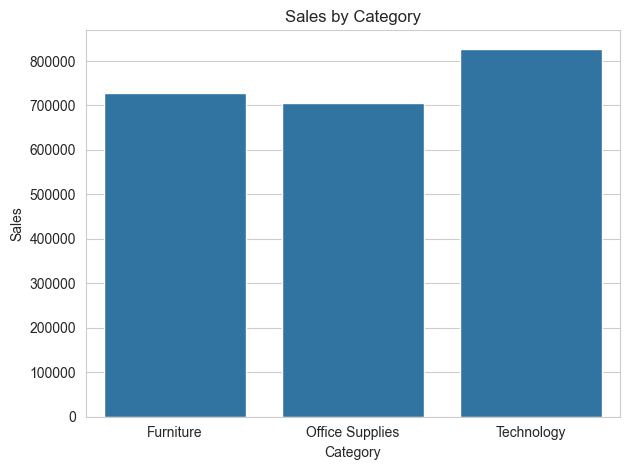

In [44]:


category_sales = df.groupby('Category')['Sales'].sum().reset_index()

sns.barplot(data=category_sales, x='Category', y='Sales')
plt.title("Sales by Category")

plt.tight_layout()
plt.savefig("../visuals/sales_by_category.png")
plt.show()

### Insight

Technology category generates the highest sales compared to Furniture and Office Supplies.
This indicates strong customer demand for technology products.

## Sales by Region

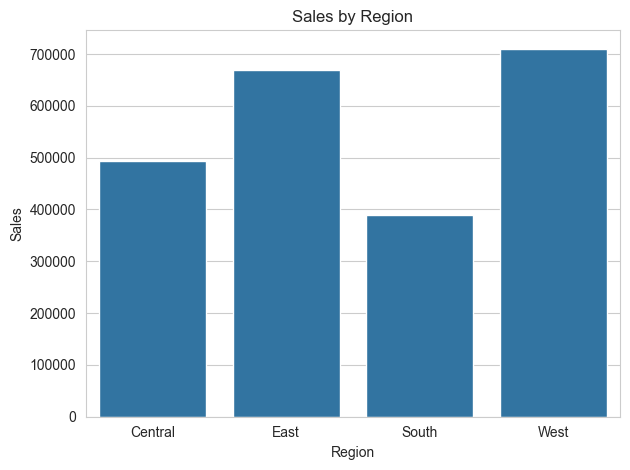

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

sns.barplot(data=region_sales, x='Region', y='Sales')
plt.title("Sales by Region")

plt.tight_layout()
plt.savefig("../visuals/region_sales.png")
plt.show()


### Insight

The West region contributes the highest sales among all regions.
This suggests strong market demand in this region.

## Monthly Sales Trend

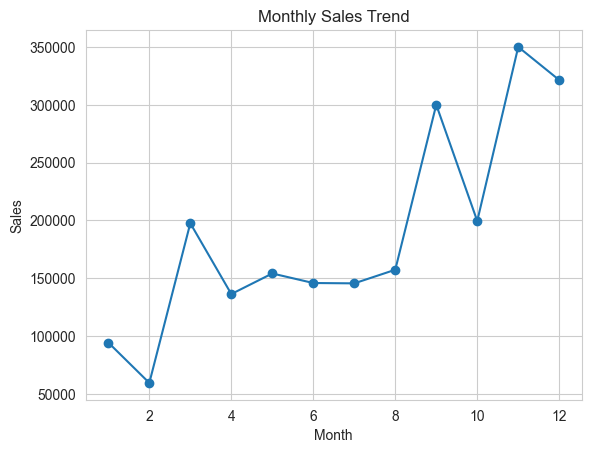

In [43]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.savefig("../visuals/monthly_sales.png")
plt.show()





### Insight

Sales fluctuate across months, indicating possible seasonal buying patterns.
Certain months show higher revenue compared to others.

## Top Sub-Categories

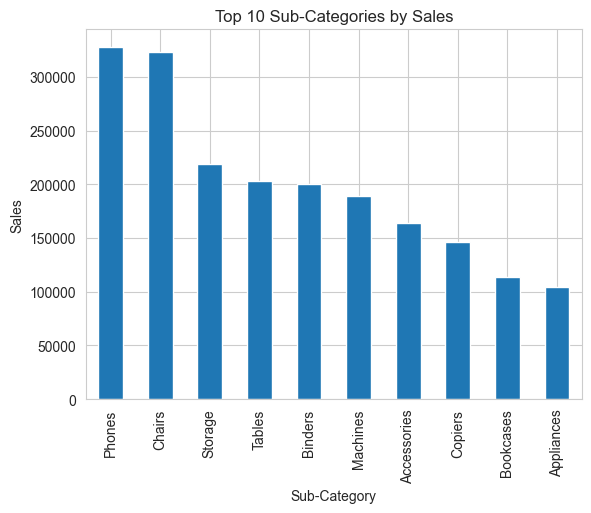

In [39]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title("Top 10 Sub-Categories by Sales")
plt.ylabel("Sales")
plt.savefig("../visuals/top_subcategories_sales.png")
plt.show()

### Insight

A few sub-categories generate significantly higher sales than others,
showing that some product types dominate revenue.

## Sales by Segment

In [ ]:
segment_sales = df.groupby('Segment')['Sales'].sum()

segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Customer Segment")
plt.ylabel("")
plt.savefig("../visuals/sales_by_segment.png")
plt.show()

### Insight

The Consumer segment contributes the largest share of total sales,
indicating that individual customers are the primary buyers.

## Top States

In [ ]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar')
plt.title("Top 10 States by Sales")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("../visuals/top_states_sales.png")
plt.show()

### Insight

Certain states contribute significantly more to total sales,
making them key markets for the business.

## Top Cities

In [ ]:
city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(10)

city_sales.plot(kind='bar')
plt.title("Top 10 Cities by Sales")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("../visuals/top_cities_sales.png")
plt.show()

### Insight

A small number of cities dominate total sales, suggesting
these cities have strong customer demand.

## Top Products

In [ ]:
product_sales = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

product_sales.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("../visuals/top_products_sales.png")
plt.show()

### Insight

A few products generate a large portion of total sales,
indicating high customer demand for those items.

## Conclusion

This project analyzed an E-commerce dataset using Python to identify
important sales trends.

Key findings:
• Technology and Office Supplies generate high revenue.
• Certain regions and cities contribute the majority of sales.
• A small number of products dominate total revenue.

These insights help businesses focus on high-performing products
and markets.